# A very basic Monte Carlo radiative transfer code, parallelized with JAX

**Monte Carlo radiative transfer (MCRT)** simulates how light moves through a scene by literally simulating many individual photon packets and tracking where each one ends up. It's a brute-force alternative to solving the radiative transfer equation analytically, and it's popular in astrophysics because it stays simple even when the physics gets complicated.

The catch is that you usually need $10^5$-$10^8$ photons for the statistics to converge. The saving grace is that **every photon's trajectory is completely independent of every other photon's** -- there is no interaction between them. That makes MCRT what's called an *embarrassingly parallel* problem: instead of a Python `for` loop over photons, we can compute every trajectory at once as one big array operation.

That's exactly what [JAX](https://github.com/google/jax) is good at. This version of the notebook builds a simulation of:

- a 3D **grid of voxels**, each with its own scattering density -- "an object" in this scene is simply wherever that density is nonzero, whatever shape it happens to trace out;
- a beam of photons flying into the grid, travelling in straight lines through empty (zero-density) space;
- **the only thing that can happen to a photon is that it scatters**, with a probability set by the density of whatever voxel it's currently passing through -- no absorption, nothing else in the scene;
- if a photon flies out of the bounding box, it is **killed** -- removed from the simulation for good.

We use `jax.vmap` to run *all* photon trajectories simultaneously, and `jax.jit` to compile that to a single kernel that runs on whatever accelerator JAX finds: an Apple Silicon Mac GPU (Metal backend) or an Nvidia GPU (CUDA backend), no code changes needed either way. (Section 0 below has an important, hard-won caveat about the Metal backend specifically for this version -- read it before cranking up the photon count.)

The physics helper functions live in [`utils/`](utils/) next to this notebook, kept short and heavily commented so you can read them as an extension of this notebook rather than a black box:

- [`utils/voxels.py`](utils/voxels.py) -- the voxel grid itself: indexing, density lookup, and a couple of simple density-field builders
- [`utils/raytracing.py`](utils/raytracing.py) -- pure geometry: ray-box intersection, and turning angles into 3D vectors
- [`utils/sampling.py`](utils/sampling.py) -- the random draws: how far a photon goes, and which way it scatters
- [`utils/transport.py`](utils/transport.py) -- the physics of one photon step (which now includes marching through the grid), and the `vmap`/`scan`/`jit` machinery that parallelizes it
- [`utils/geometry.py`](utils/geometry.py) -- pulls a few real example paths out of the simulation output, for plotting
- [`utils/plotting.py`](utils/plotting.py) -- plain matplotlib helpers
- [`utils/device.py`](utils/device.py) -- reports which backend/GPU JAX is using

## 0. Setup, and which device is JAX actually using?

Run this first. If a GPU is available, JAX will use it automatically -- nothing below has to change between a Mac, a Linux box with an Nvidia GPU, or a laptop with no GPU at all.

**A caveat specific to this version, measured on an Apple M3 Pro:** marching through a voxel grid needs a *nested* loop -- for every possible scattering event (`n_bounces`), march through the grid in small steps (`n_substeps`) to find out where it happens (see Section 5). That nested `lax.scan`-inside-`lax.scan`, run under `vmap` across many photons, compiles and runs fine on CPU and should be fine on a mature Nvidia CUDA install, but the **experimental** `jax-metal` backend hangs indefinitely once `n_photons * n_bounces * n_substeps` gets much past about 2 million -- confirmed by timing runs from a few thousand up past where it never returned. This notebook's default parameters are deliberately kept under that ceiling (around 1 million) so it runs everywhere; if you're on CPU or CUDA, Section 6 says exactly where it's safe to turn that up by 100x or more.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
from jax import random
import matplotlib.pyplot as plt

from utils.device import print_device_report
from utils import sampling, raytracing, voxels, transport, geometry, plotting

plt.rcParams["figure.figsize"] = (6, 4)

_ = print_device_report()

Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!


Metal device set to: Apple M3 Pro

systemMemory: 18.00 GB
maxCacheSize: 6.66 GB

JAX backend : METAL
Devices     : [METAL(id=0)]


W0000 00:00:1788615567.614455  532471 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1788615567.627612  532471 service.cc:145] XLA service 0x7d418f600 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788615567.627621  532471 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1788615567.628683  532471 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1788615567.628689  532471 mps_client.cc:384] XLA backend will use up to 14301773824 bytes on device 0 for SimpleAllocator.


In [2]:
simulate_photons_jit = jax.jit(transport.simulate_photons, static_argnums=(1, 2, 3))


In [3]:
import time

N_PHOTONS = 3_000      # keep N_PHOTONS * N_BOUNCES * N_SUBSTEPS below ~1e6 on the Metal backend -- see Section 0
N_BOUNCES = 25            # max scattering events per photon
N_SUBSTEPS = 15             # ray-marching resolution per possible event -- see Section 4
N_VOXELS = 30                 # grid resolution per axis
BOX_MIN = jnp.array([-10.0, -10.0, -10.0])
BOX_MAX = jnp.array([10.0, 10.0, 10.0])
BEAM_RADIUS = 5.0

density_grid = voxels.make_sphere_density_grid(
    N_VOXELS, BOX_MIN, BOX_MAX, center=(0.0, 0.0, 0.0), radius=4.0, density=0.01)

t0 = time.perf_counter()
pos, direction, energy, n_scatter, status, path = simulate_photons_jit(
    random.PRNGKey(1), N_PHOTONS, N_BOUNCES, N_SUBSTEPS, density_grid, BOX_MIN, BOX_MAX, BEAM_RADIUS)
pos.block_until_ready()
print(f"first call (includes JIT compilation): {time.perf_counter() - t0:.3f} s")

t0 = time.perf_counter()
pos, direction, energy, n_scatter, status, path = simulate_photons_jit(
    random.PRNGKey(2), N_PHOTONS, N_BOUNCES, N_SUBSTEPS, density_grid, BOX_MIN, BOX_MAX, BEAM_RADIUS)
pos.block_until_ready()
print(f"second call (compiled, pure run):      {time.perf_counter() - t0:.4f} s "
      f"for {N_PHOTONS:,} photons x {N_BOUNCES} bounces x {N_SUBSTEPS} substeps")

first call (includes JIT compilation): 4.394 s
second call (compiled, pure run):      3.8516 s for 3,000 photons x 25 bounces x 15 substeps


In [20]:
import numpy as np
from utils import fits_cube, voxels, sampling, transport
import jax, jax.numpy as jnp
from jax import random

# 1. real cloud -> a faint (optically thin) scattering screen
cube = fits_cube.load_cube("realistic_nh_cube_500asec_10kpc_dz0p05.fits")
N_VOXELS = 30
density_grid, box_min, box_max = voxels.from_fits_cube(cube, n_voxels=N_VOXELS, peak_density=0.02)

# 2. aim the pencil beam at the resampled grid's own density peak, not the box center --
#    from_fits_cube discards the FITS's arcsec/kpc coordinates when remapping onto the plain box
peak_idx = np.unravel_index(np.argmax(np.asarray(density_grid)), density_grid.shape)
voxel_size = (np.asarray(box_max) - np.asarray(box_min)) / N_VOXELS
aim_point = jnp.array(np.asarray(box_min) + (np.array(peak_idx) + 0.5) * voxel_size)

# 3. grain + energy assumption -> deep in the Mie (forward-peaked) regime, as established earlier
GRAIN_RADIUS_UM = 0.1
ENERGY_KEV = 1.0
x = sampling.size_parameter_from_energy_kev(ENERGY_KEV, GRAIN_RADIUS_UM)

# 4. point-source pencil beam through the cloud
simulate_photons_jit = jax.jit(transport.simulate_photons,
    static_argnames=("n_photons", "n_bounces", "n_substeps", "scattering_model"))

pos, direction, energy, n_scatter, status, path = simulate_photons_jit(
    random.PRNGKey(0), n_photons=15000, n_bounces=3, n_substeps=25,
    density_grid=density_grid, box_min=box_min, box_max=box_max,
    beam_radius=0.05, beam_divergence=0.0, aim_point=aim_point,
    scattering_model="mie", energy_min=x, energy_max=x, mie_g_max=0.85)


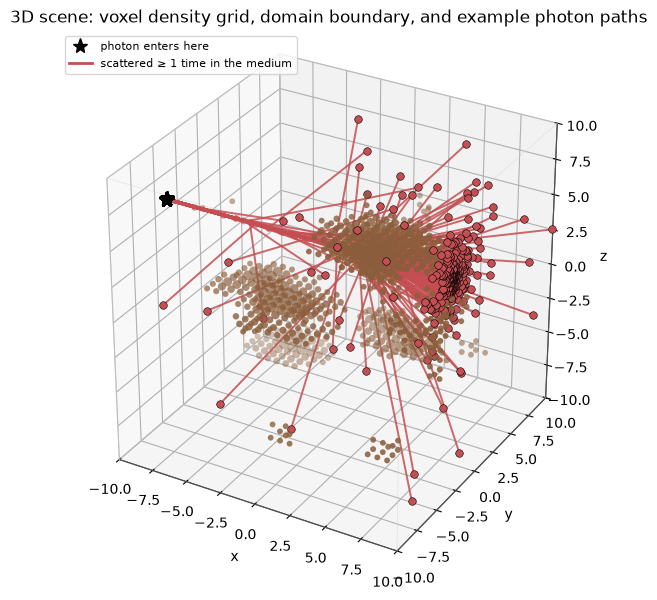

In [21]:
# --- 1. 3D photon trajectories through the FITS-derived cloud (same as Section 7) ---
example_paths = geometry.extract_example_paths(path, status, n_examples=300, n_scatter=n_scatter)

fig = plt.figure(figsize=(8, 7))
plotting.plot_3d_scene(example_paths, density_grid, box_min, box_max, voxel_alpha=1)
plt.show()



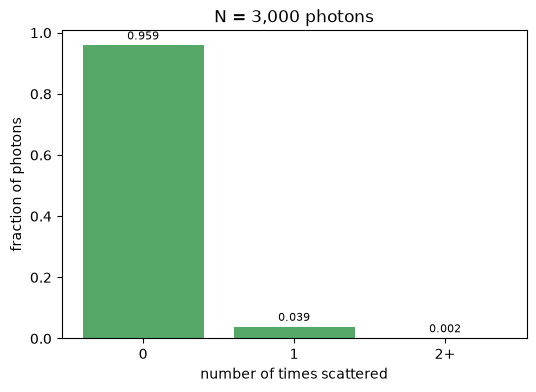

In [9]:
# --- 2. how many times each photon scattered (Section 8) ---
plotting.plot_n_scatter_histogram(n_scatter)
plt.show()



still active (should be close to 0): 0.0000
scattered >= 1 time: 0.0407


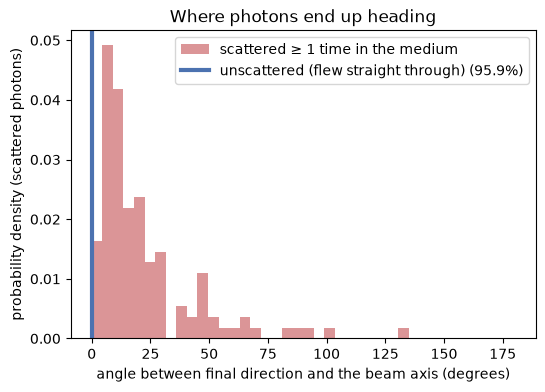

In [8]:
import jax.numpy as jnp
print(f"still active (should be close to 0): {float(jnp.mean(status == transport.ACTIVE)):.4f}")
print(f"scattered >= 1 time: {float(jnp.mean(n_scatter >= 1)):.4f}")

# --- 3. exit-angle distribution: how much photons got redirected (Section 9) ---
plotting.plot_exit_angle_comparison(direction, n_scatter)
plt.show()

## 7. A 3D picture of the scene

Every photon's full path was recorded as part of that one batched run above -- `geometry.extract_example_paths` just pulls a handful of them out and trims off the frozen tail each photon leaves behind after it's killed. The pale cloud of points is the voxel grid itself: one dot per occupied voxel (there's no true volume renderer in plain matplotlib, so this is the honest, basic substitute -- see `plotting.plot_voxel_grid`). Blue paths flew straight through and never scattered; red paths bounced around inside the density field before finding their way back out.

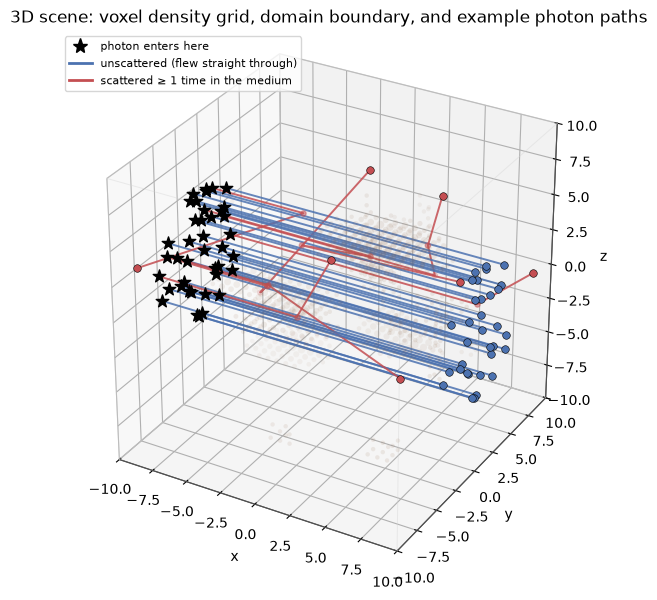

In [7]:
example_paths = geometry.extract_example_paths(path, status, n_examples=40)

fig = plt.figure(figsize=(8, 7))
plotting.plot_3d_scene(example_paths, density_grid, BOX_MIN, BOX_MAX)
plt.show()

## 8. Where did the photons go?

With no absorption, every photon is eventually killed by leaving the domain (check the printed "still active" fraction below -- it should be close to zero; if it isn't, `N_BOUNCES` needs to be larger). What varies is how many times each one scattered on the way -- a photon deep inside a dense region can bounce around for a while before it randomly walks its way back out.

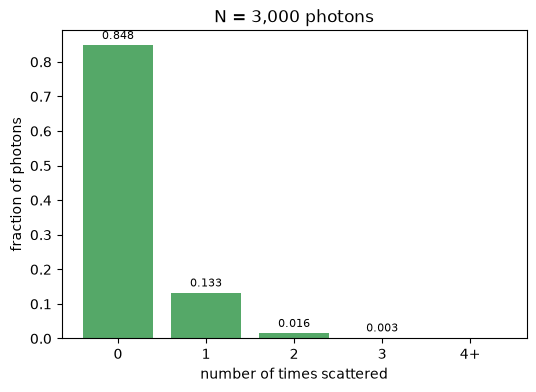

still active (should be close to 0): 0.0000
scattered >= 1 time: 0.1517


In [8]:
plotting.plot_n_scatter_histogram(n_scatter)
plt.show()

print(f"still active (should be close to 0): {float(jnp.mean(status == transport.ACTIVE)):.4f}")
print(f"scattered >= 1 time: {float(jnp.mean(n_scatter >= 1)):.4f}")

## 9. Where photons end up heading

The angle between each photon's final direction and the beam axis it started on. Unscattered photons never changed direction, so they pile up in a delta function at $0°$. Scattered photons lose essentially all memory of the original beam direction, spreading out over a wide range of angles -- especially after more than one bounce.

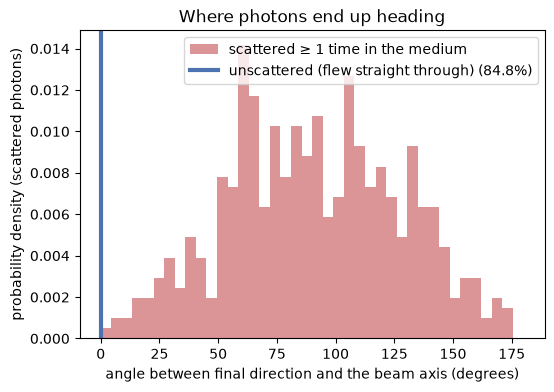

In [9]:
plotting.plot_exit_angle_comparison(direction, n_scatter)
plt.show()

## 10. Adjusting the scene

Everything about "what objects exist" now lives in one array, `density_grid` -- built once, up front, in plain Python/numpy (see [`utils/voxels.py`](utils/voxels.py)), then handed to `simulate_photons` like any other input. There's no special-cased "object position" parameter to move anymore; instead:

- **Move or reshape the object**: change the arguments to `make_sphere_density_grid` (`center`, `radius`, `density`), use `make_slab_density_grid` for a different shape, or build a completely custom `(n_voxels, n_voxels, n_voxels)` array by hand -- anything nonnegative is a valid density field, so multiple objects, a hollow shell, random clumps, or real observational data all work with no changes to `transport.py`.
- **How photons are created**: `beam_direction`, `beam_divergence`, `aim_point`, `beam_radius`, `energy_min`/`energy_max` all still work exactly as in the previous version -- `simulate_photons`'s signature just gained `n_substeps` and swapped its old `dust_center` for `density_grid`/`box_min`/`box_max`.

A quick example: a smaller, denser grain, offset to one side.

scattered >= 1 time: 0.2123


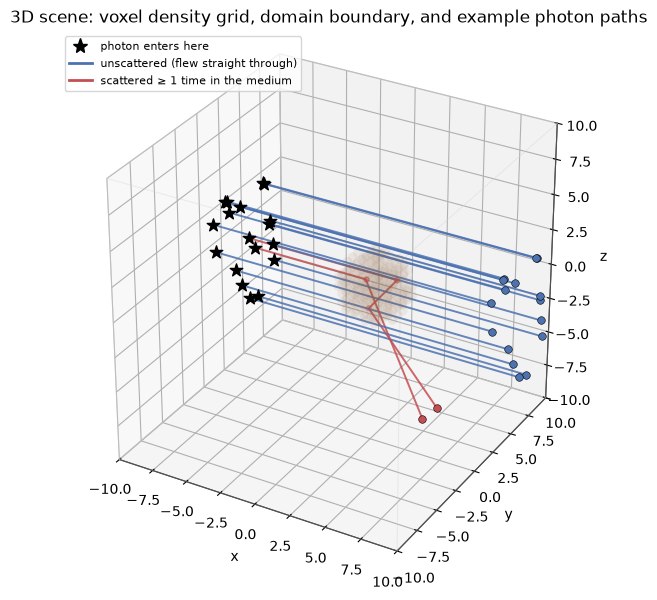

In [10]:
moved_grid = voxels.make_sphere_density_grid(
    N_VOXELS, BOX_MIN, BOX_MAX, center=(0.0, 5.0, -2.0), radius=2.5, density=0.6)

pos_b, direction_b, energy_b, n_scatter_b, status_b, path_b = simulate_photons_jit(
    random.PRNGKey(3), N_PHOTONS, N_BOUNCES, N_SUBSTEPS, moved_grid, BOX_MIN, BOX_MAX, BEAM_RADIUS,
    aim_point=jnp.array([0.0, 5.0, -2.0]))  # aim the beam at the grain's new position

print(f"scattered >= 1 time: {float(jnp.mean(n_scatter_b >= 1)):.4f}")

example_paths_b = geometry.extract_example_paths(path_b, status_b, n_examples=18)
fig = plt.figure(figsize=(8, 7))
plotting.plot_3d_scene(example_paths_b, moved_grid, BOX_MIN, BOX_MAX)
plt.show()

## 11. Recap, and where this goes next

The whole simulation is: sample a target optical depth; march through the grid, accumulating optical depth, until either that target is reached (scatter, pick a new isotropic direction, repeat) or the box boundary is (die). What makes it a *parallel GPU* code rather than a slow Python loop is entirely structural, not physical -- the same recipe as every version of this notebook:

- write the single-photon update with array ops (`jnp.where`) instead of `if`/`else`,
- thread an explicit PRNG key through it instead of relying on global random state,
- wrap the per-photon bounce loop (and now, the per-event marching loop) in `jax.lax.scan`,
- wrap the per-photon function in `jax.vmap` to batch over photons,
- wrap the whole thing in `jax.jit` to compile it to one kernel.

The one place that structural recipe currently runs into trouble is the experimental Metal backend specifically (Section 0) -- worth remembering if you extend this: **every additional nested `lax.scan` makes the Metal ceiling on total photons x steps lower**, so a more elaborate marching scheme (adaptive step sizes, sub-voxel interpolation, more than one grid) will need either a smaller `n_photons` on Metal, or running on CPU/CUDA instead.

This code is deliberately minimal -- fundamentals only. Natural next steps, none of which change the structure above, only `photon_step` and the density field:

- **Bring absorption back**: give each voxel a single-scattering albedo alongside its density, so a fraction of scattering events kill the photon on the spot instead of always redirecting it.
- **Actually use `energy`**: carried along unchanged right now (nothing consumes it); once absorption exists, each event could deposit a fraction of a photon's energy in that voxel instead of an all-or-nothing kill -- accumulate that and you have a 3D radiation field, not just a photon count.
- **Wavelength dependence**: let `energy` double as a wavelength, and make the density field itself wavelength-dependent (real dust opacity is a strong function of wavelength).
- **Better marching**: sub-voxel interpolation between cell centers, or an exact analytic per-cell crossing (`DDA`/Amanatides-Woo voxel traversal) instead of a fixed-step Riemann sum, would need fewer `n_substeps` for the same accuracy.
- **Temperature**: accumulate absorbed energy per voxel to solve for its temperature (the classic Bjorkman & Wood 2001 algorithm) -- a natural next step once absorption is back in the model.

Filename: realistic_nh_cube_500asec_10kpc_dz0p05.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  TOTAL_NH      1 PrimaryHDU      44   (500, 500, 200)   float32   
  1  NH_MAP        1 ImageHDU        24   (500, 500)   float32   
  2  HI_NH_MAP     1 ImageHDU        24   (500, 500)   float32   
  3  MOL_NH_MAP    1 ImageHDU        24   (500, 500)   float32   
  4  MC1_NH        1 ImageHDU        25   (500, 500)   float32   
  5  MC2_NH        1 ImageHDU        25   (500, 500)   float32   
  6  MC3_NH        1 ImageHDU        25   (500, 500)   float32   
  7  MC4_NH        1 ImageHDU        25   (500, 500)   float32   
  8  CLOUDS        1 BinTableHDU     50   4R x 14C   [16A, D, D, D, D, D, D, D, D, D, D, J, J, K]   

--- TOTAL_NH ---
  shape: (200, 500, 500)   dtype: >f4   unit: cm-2
  min=1.6054e+19  max=4.5683e+22  mean=1.1812e+20
  BTYPE: DELTA_NH
  SIMTYPE: TURBULENT
  NMCLOUD: 4
  ZMINKPC: 0.0
  ZMAXKPC: 10.0
  DZKPC: 0.05

--- NH_MAP ---
  shape: (500, 500

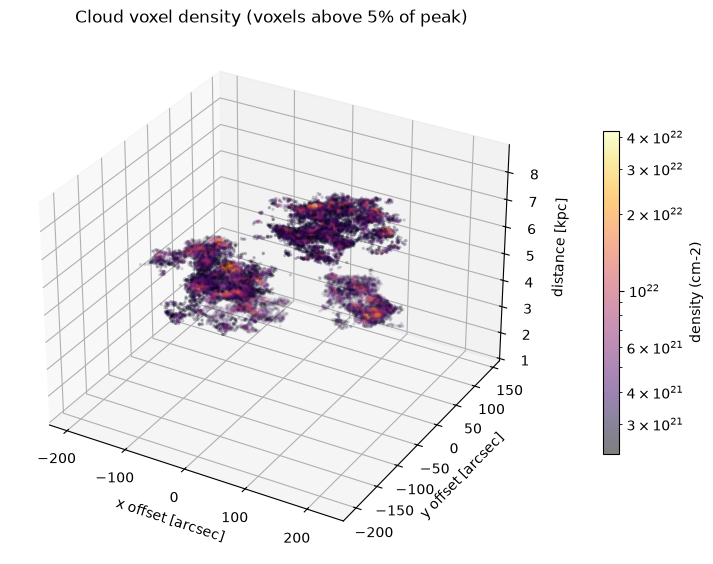

In [12]:
from utils import fits_cube
import matplotlib.pyplot as plt

path = "realistic_nh_cube_500asec_10kpc_dz0p05.fits"

# 1. Dump everything the FITS file contains (all HDUs, header keywords, the CLOUDS table)
fits_cube.print_fits_info(path)

# 2. Load the main density cube + its physical axes (arcsec, arcsec, kpc)
cube = fits_cube.load_cube(path)

# 3. Quick stats: grid shape, extent, density range, nonzero fraction
fits_cube.print_cube_summary(cube)

# 4. 3D plot of the cloud, colored/sized by density (log scale)
fits_cube.plot_cloud_3d(cube, density_threshold_frac=0.05)
plt.show()
